# Comparing optimizer updates: warmup and spike response

This notebook visualizes the per-step parameter update produced by **Muon**, **SOAP**, **REKLS**, **LaProp**, and the reference **AdamW** in two regimes:

1. **Per-step trajectory** at a single gradient scale — how quickly each optimizer reaches its steady-state update magnitude.
2. **Spike response** — how each optimizer reacts to a single gradient that is 1000× the normal scale, and how many steps it takes to recover.

Setup:

- A single 2-D parameter of shape `(128, 64)` is initialized once and cloned per optimizer/run.
- Each run feeds the parameter a sequence of i.i.d. Gaussian gradients.
- After every step we record the **update**, defined as `p_before - p_after` (the negative of `lr * effective_update`).
- All optimizers use `lr = 1.0`, `weight_decay = 0.0` so the recorded value is the raw per-step update.

What to look for:

- **AdamW**: update RMS saturates to roughly `lr` regardless of gradient scale — Adam normalizes by the running second moment, behaving like a signed gradient at steady state.
- **LaProp**: saturates to ~`lr` like AdamW (it also normalizes by the running second moment, but does so on the gradient *before* the first-moment EMA). Configured here with `β₂ = 0.65` (vs `0.95` for AdamW) so its second-moment EMA forgets a spike in ~3 steps instead of ~20 — spike recovery is therefore much faster.
- **Muon**: the update is an orthogonal matrix times a shape-dependent constant. Its spectral norm is determined entirely by `scale_mode`, not by the gradient magnitude.
- **SOAP / REKLS**: Adam-like in the eigenbasis of the gradient covariance. Update RMS is similar to AdamW once the Kronecker factors warm up, but the singular-value spectrum is shaped by the preconditioner.

Dependencies beyond the repo: `matplotlib` (install with `uv pip install matplotlib` or `pip install matplotlib`).


In [1]:
import os
import matplotlib.pyplot as plt
import numpy as np
import torch

from emerging_optimizers.orthogonalized_optimizers.muon import Muon
from emerging_optimizers.scalar_optimizers.laprop import LaProp
from emerging_optimizers.soap.rekls import REKLS
from emerging_optimizers.soap.soap import SOAP

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# device = "cpu"
dtype = torch.float32
print(f"device={device}")

# os.environ["TORCH_ALLOW_TF32_CUBLAS_OVERRIDE"] = "0"

device=cuda


In [2]:
PARAM_SHAPE = (128, 64)
N_STEPS = 100
SEED = 0

# All optimizers share lr=1.0 and weight_decay=0.0 so the recorded update is the raw
# update before learning-rate scaling.
#
# Beta choices:
#   - AdamW / SOAP / REKLS: betas=(0.9, 0.95) — same second-moment time constant for
#     apples-to-apples comparison.
#   - LaProp: betas=(0.9, 0.65) — deliberately shorter beta2 so its `v` forgets a spike
#     quickly. Steady-state behavior is similar to AdamW; spike recovery is much faster
#     because the inflated `v` decays in ~3 steps (vs ~20 at beta2=0.95).
#   - Muon: momentum=0.95 (analogous to beta1 of the Adam-like optimizers).
LR = 1.0


def make_optimizers(param: torch.Tensor) -> dict[str, torch.optim.Optimizer]:
    return {
        "AdamW": torch.optim.AdamW([param], lr=LR, betas=(0.9, 0.95), eps=1e-8, weight_decay=0.0),
        "LaProp": LaProp([param], lr=LR, betas=(0.9, 0.65), eps=1e-8, weight_decay=0.0),
        "Muon": Muon([param], lr=LR, momentum=0.95, weight_decay=0.0),
        "SOAP": SOAP([param], lr=LR, betas=(0.9, 0.95), shampoo_beta=0.95, weight_decay=0.0, fp32_matmul_prec="highest", use_kl_shampoo=True),
        "REKLS": REKLS([param], lr=LR, betas=(0.9, 0.95), shampoo_beta=0.95, weight_decay=0.0),
    }


OPTIMIZER_NAMES = list(make_optimizers(torch.zeros(PARAM_SHAPE, device=device)).keys())
print("Optimizers:", OPTIMIZER_NAMES)


Optimizers: ['AdamW', 'LaProp', 'Muon', 'SOAP', 'REKLS']


In [3]:
def run_optimizer(
    optimizer_name: str,
    grad_scale: float,
    n_steps: int = N_STEPS,
    shape: tuple[int, int] = PARAM_SHAPE,
    seed: int = SEED,
) -> torch.Tensor:
    """Drive `optimizer_name` with i.i.d. Gaussian gradients of std=`grad_scale` and return the per-step updates.

    The same `seed` is used for every optimizer, so they all see the exact same gradient sequence.
    The returned tensor has shape `(n_steps, *shape)` and contains `p_before - p_after` per step.
    """
    g = torch.Generator(device=device).manual_seed(seed)

    param = torch.zeros(shape, device=device, dtype=dtype, requires_grad=True)
    opt = make_optimizers(param)[optimizer_name]

    updates = torch.empty((n_steps, *shape), device=device, dtype=dtype)
    for i in range(n_steps):
        with torch.no_grad():
            grad = torch.randn(shape, device=device, dtype=dtype, generator=g) * grad_scale
        param.grad = grad
        p_before = param.detach().clone()
        opt.step()
        updates[i] = p_before - param.detach()
    return updates.cpu()


# Sanity check: a single short run.
_smoke = run_optimizer("Muon", grad_scale=1.0, n_steps=5)
print("smoke updates shape:", tuple(_smoke.shape))

smoke updates shape: (5, 128, 64)


## Per-step update trajectory

Drive every optimizer with the same i.i.d. Gaussian gradients (`std = 1`, same seed across optimizers) and record the per-step update. (All five optimizers are scale-invariant to the gradient magnitude in steady state — sweeping over magnitudes would just produce overlapping curves at the same value, so we run only at `grad_scale = 1.0` here.)


In [4]:
WARMUP = 30
TRAJECTORY_SCALE = 1.0


def update_rms(u: torch.Tensor) -> torch.Tensor:
    # u shape: (n_steps, m, n) → per-step RMS over the (m, n) elements.
    return u.flatten(1).square().mean(dim=1).sqrt()


def update_spectral_norm(u: torch.Tensor) -> torch.Tensor:
    # Largest singular value per step.
    return torch.linalg.matrix_norm(u, ord=2)


# trajectory_updates[name] is a tensor of shape (N_STEPS, *PARAM_SHAPE) on CPU.
trajectory_updates: dict[str, torch.Tensor] = {}
for name in OPTIMIZER_NAMES:
    trajectory_updates[name] = run_optimizer(name, grad_scale=TRAJECTORY_SCALE)
    print(f"finished {name}")


finished AdamW
finished LaProp
finished Muon
finished SOAP
finished REKLS


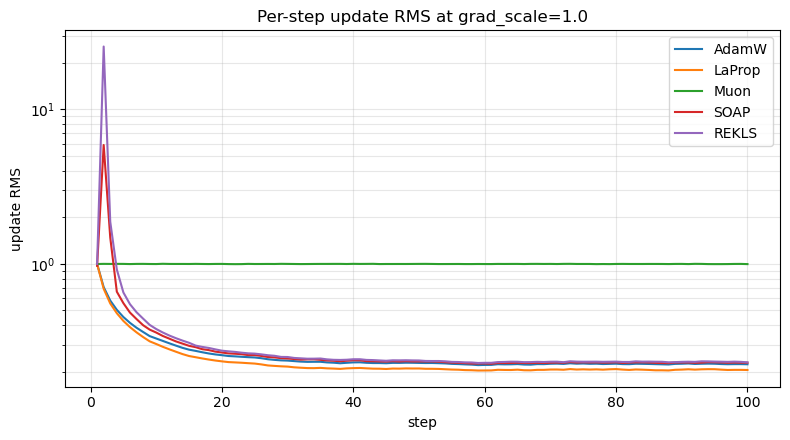

In [5]:
fig, ax = plt.subplots(figsize=(8, 4.5))
for name in OPTIMIZER_NAMES:
    rms_traj = update_rms(trajectory_updates[name]).numpy()
    ax.plot(np.arange(1, N_STEPS + 1), rms_traj, label=name)

ax.set_yscale("log")
ax.set_xlabel("step")
ax.set_ylabel("update RMS")
ax.set_title(f"Per-step update RMS at grad_scale={TRAJECTORY_SCALE}")
ax.grid(True, which="both", alpha=0.3)
ax.legend()
fig.tight_layout()
plt.show()


## Sudden gradient spike — sweep over spike timing and magnitude

Inject a single anomalously large gradient on step `spike_at` (one of `{10, 50, 100}` — covering during warmup, just past warmup, and deep in steady state), at magnitudes spanning `SPIKE_SCALE ∈ {1e2, 1e3, 1e4, 1e5}`. Continue with normal `randn()` gradients for the rest of the run and watch how each optimizer recovers.

Predictions:

- **AdamW / LaProp**: the spike step produces a large update because `exp_avg_sq` lags the gradient. After absorbing the spike into `exp_avg_sq`, the denominator stays inflated by `~SPIKE_SCALE`, suppressing subsequent updates until `exp_avg_sq` decays back over `~1/(1 - β₂)` steps. Larger spikes take proportionally longer to forget.
- **Muon**: orthogonalization removes the magnitude entirely, so the spike's effect on the *update size* should be ≈ none, regardless of scale or timing.
- **SOAP / REKLS**: both the Kronecker factors (`L`, `R`) and the inner Adam's `exp_avg_sq` ingest the spike, so recovery depends on `shampoo_beta` and `β₂`. Recovery time should grow with spike magnitude. Spiking during warmup (`spike_at=10`) may behave differently from spiking in steady state since the factors haven't fully accumulated yet.


In [6]:
SPIKE_AT_LIST = [10, 50, 100]
SPIKE_SCALES = [1e2, 1e3, 1e4, 1e5]
SPIKE_TOTAL_STEPS = 200
NORMAL_SCALE = 1.0


def run_with_spike(
    optimizer_name: str,
    spike_at: int,
    spike_scale: float,
    normal_scale: float = NORMAL_SCALE,
    n_steps: int = SPIKE_TOTAL_STEPS,
    shape: tuple[int, int] = PARAM_SHAPE,
    seed: int = SEED,
) -> torch.Tensor:
    """Same driver as `run_optimizer`, except step `spike_at` uses `spike_scale × normal_scale` instead of `normal_scale`."""
    g = torch.Generator(device=device).manual_seed(seed)

    param = torch.zeros(shape, device=device, dtype=dtype, requires_grad=True)
    opt = make_optimizers(param)[optimizer_name]

    updates = torch.empty((n_steps, *shape), device=device, dtype=dtype)
    for i in range(n_steps):
        scale = spike_scale * normal_scale if i == spike_at else normal_scale
        with torch.no_grad():
            grad = torch.randn(shape, device=device, dtype=dtype, generator=g) * scale
        param.grad = grad
        p_before = param.detach().clone()
        opt.step()
        updates[i] = p_before - param.detach()
    return updates.cpu()


# spike_results[(spike_at, spike_scale)][name] is a tensor of shape (SPIKE_TOTAL_STEPS, *PARAM_SHAPE).
spike_results: dict[tuple[int, float], dict[str, torch.Tensor]] = {}
for spike_at in SPIKE_AT_LIST:
    for spike_scale in SPIKE_SCALES:
        spike_results[(spike_at, spike_scale)] = {}
        for name in OPTIMIZER_NAMES:
            spike_results[(spike_at, spike_scale)][name] = run_with_spike(name, spike_at, spike_scale)
    print(f"finished spike_at={spike_at}")


finished spike_at=10
finished spike_at=50
finished spike_at=100


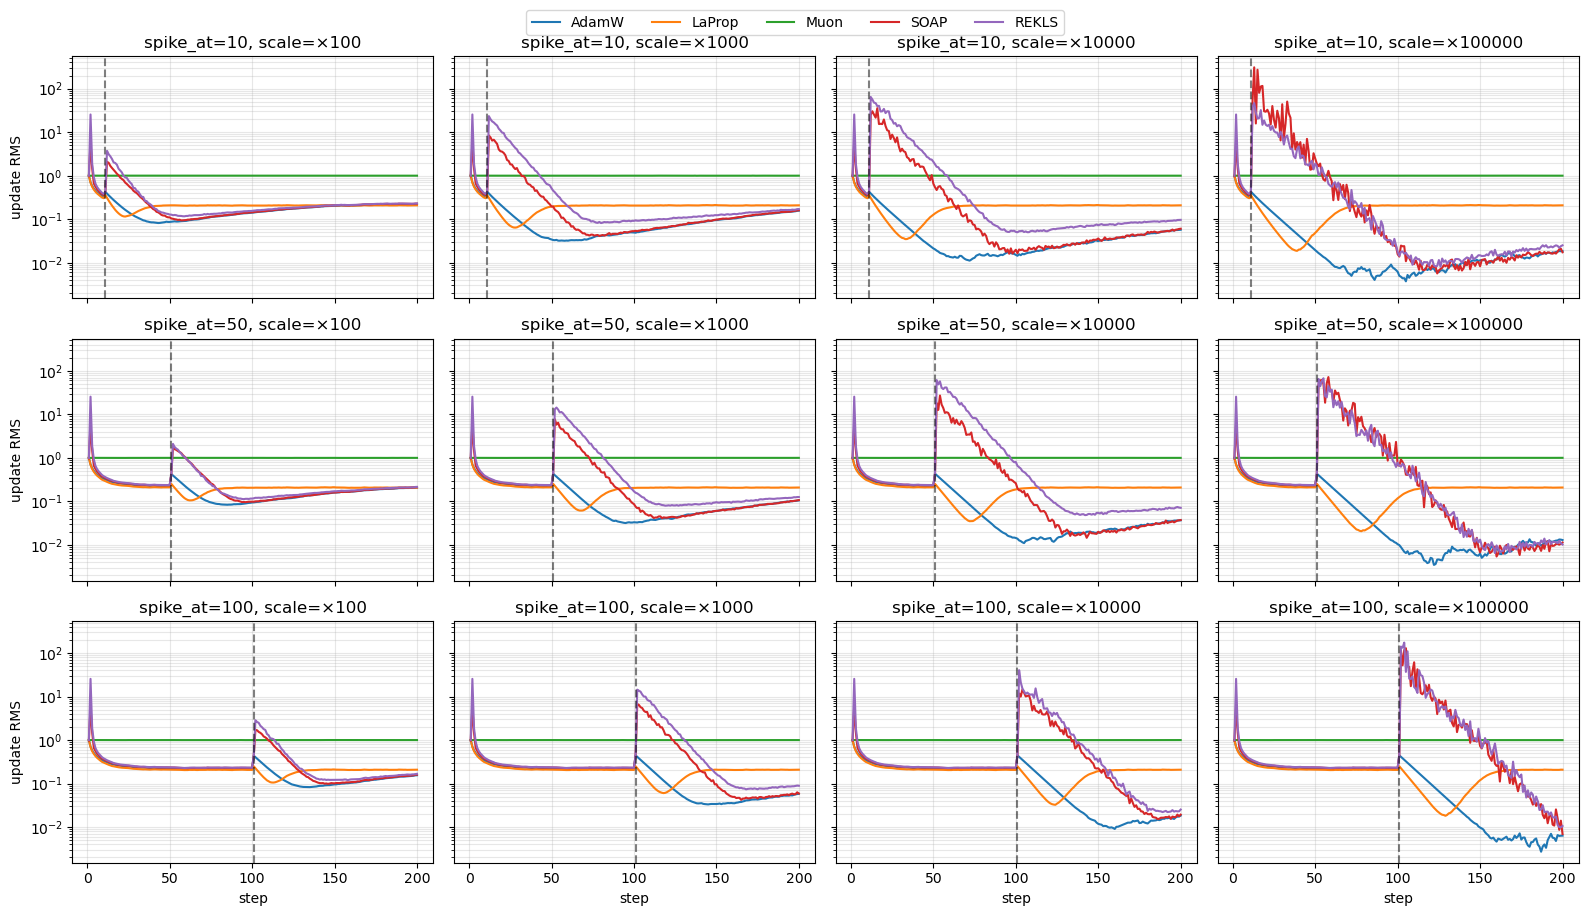

In [7]:
fig, axes = plt.subplots(len(SPIKE_AT_LIST), len(SPIKE_SCALES), figsize=(16, 9), sharex=True, sharey=True)
steps_x = np.arange(1, SPIKE_TOTAL_STEPS + 1)

for i, spike_at in enumerate(SPIKE_AT_LIST):
    for j, spike_scale in enumerate(SPIKE_SCALES):
        ax = axes[i, j]
        for name in OPTIMIZER_NAMES:
            rms = update_rms(spike_results[(spike_at, spike_scale)][name]).numpy()
            ax.plot(steps_x, rms, label=name)
        ax.axvline(spike_at + 1, color="k", linestyle="--", alpha=0.5)
        ax.set_yscale("log")
        ax.set_title(f"spike_at={spike_at}, scale=×{spike_scale:g}")
        ax.grid(True, which="both", alpha=0.3)
        if i == len(SPIKE_AT_LIST) - 1:
            ax.set_xlabel("step")
        if j == 0:
            ax.set_ylabel("update RMS")

handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=len(OPTIMIZER_NAMES), bbox_to_anchor=(0.5, 1.02))
fig.tight_layout()
plt.show()


### Recovery summary

For each `(optimizer, spike_at, spike_scale)` cell, report the number of steps after the spike before the update RMS returns within 10% of the **post-spike steady-state RMS** (mean of the last 30 steps of the trajectory). Using the post-spike steady state as the reference makes the metric meaningful even when the spike happens during warmup, where the pre-spike "steady-state" isn't yet established.


In [8]:
TOLERANCE = 0.10
STEADY_WINDOW = 30  # last N steps of trajectory used to define post-spike steady-state RMS


def recovery_steps(rms_traj: np.ndarray, spike_at: int) -> int | str:
    target = rms_traj[-STEADY_WINDOW:].mean()
    post = rms_traj[spike_at + 1 :]
    within = np.where(np.abs(post - target) <= TOLERANCE * target)[0]
    return int(within[0]) + 1 if len(within) else f">{len(post)}"


header_scales = "  ".join(f"{s:>8.0e}" for s in SPIKE_SCALES)
print("Recovery time (steps after spike to return within 10% of post-spike steady-state RMS):")
print(f"  {'optimizer':<8}  {'spike_at':>8}  {header_scales}")
print("  " + "-" * (10 + 10 + len(header_scales)))
for name in OPTIMIZER_NAMES:
    for k, spike_at in enumerate(SPIKE_AT_LIST):
        cells = []
        for spike_scale in SPIKE_SCALES:
            rms = update_rms(spike_results[(spike_at, spike_scale)][name]).numpy()
            cells.append(f"{recovery_steps(rms, spike_at):>8}")
        opt_label = name if k == 0 else ""
        print(f"  {opt_label:<8}  {spike_at:>8}  " + "  ".join(cells))
    print()


Recovery time (steps after spike to return within 10% of post-spike steady-state RMS):
  optimizer  spike_at     1e+02     1e+03     1e+04     1e+05
  ----------------------------------------------------------
  AdamW           10         7        13        26        41
                  50         9        19        33        46
                 100        15        28        44        56

  LaProp          10         4         4         4         4
                  50         1         1         1         1
                 100         1         1         1         1

  Muon            10         1         1         1         1
                  50         1         1         1         1
                 100         1         1         1         1

  SOAP            10        25        43        68        89
                  50        27        48        74        96
                 100        32        56        77        80

  REKLS           10        26        51        72    

## Takeaways

- **AdamW** is approximately scale-invariant in steady state, but a 1000× spike is *not* free: the spike step itself produces a large update because `exp_avg_sq` lags the gradient, and the inflated `exp_avg_sq` then suppresses subsequent updates until it decays back over `~1/(1 - β₂)` steps. Recovery time scales roughly logarithmically with spike magnitude.
- **LaProp** with the short `β₂ = 0.65` used here recovers in essentially one step at steady-state spikes (and ~4 steps if the spike lands during warmup). With matching `β₂ = 0.95` it would behave similarly to AdamW. The shorter second-moment time constant is the only knob doing the work — LaProp's pre-normalize-then-momentum order doesn't help much by itself.
- **Muon** is exactly scale-invariant after the Newton–Schulz iteration: orthogonalization throws away the gradient's magnitude, leaving only the shape-dependent scaling factor (`spectral` mode → `sqrt(max(m, n))`). The 1000× spike barely registers in the update RMS, though it can rotate the momentum-driven update *direction* for a few steps.
- **SOAP / REKLS** are scale-invariant in steady state (Adam runs in the preconditioned space), but the singular-value spectrum of the update is flatter than AdamW's because of the Kronecker-factored preconditioner. A gradient spike pollutes both the Kronecker factors and the inner Adam second moment, so they take roughly `1/(1 - shampoo_beta)` steps to forget it. On CUDA, the `fp32_matmul_prec="highest"` workaround (or the targeted fix in `update_kronecker_factors_kl_shampoo`) is required to avoid TF32-induced divergence under high-magnitude spikes; see `preconditioner-eigenbasis-spike.ipynb` for the diagnostic.

Knobs to play with:

- Change `PARAM_SHAPE` — Muon's update scale is `sqrt(max(m, n))` under `scale_mode='spectral'`, so a non-square matrix highlights the dependence on the larger dimension.
- Set `momentum=0.0` on Muon to see the warmup transient disappear.
- Change LaProp's `betas[1]` to `0.95` to see its spike recovery slow down to match AdamW.
- Pass a non-i.i.d. gradient (e.g. low-rank or heavy-tailed) and watch SOAP / REKLS adapt their preconditioner over time.
- Move `SPIKE_AT` earlier (before the moving averages have warmed up) or later, and try `SPIKE_SCALE` in {10, 100, 1000, 10000} to see how the recovery time scales with the spike magnitude.

See also `preconditioner-eigenbasis-spike.ipynb` for a companion notebook that looks at how the SOAP/REKLS Kronecker factor eigenbasis evolves around a spike, and `tf32-eigval-precision-loss.ipynb` for a standalone demonstration of the TF32 precision issue underlying the SOAP CUDA divergence.
